# **COMP 2211 Introduction to Artificial Intelligence** #
## Lab 9 - Deep Learning using PyTorch ##
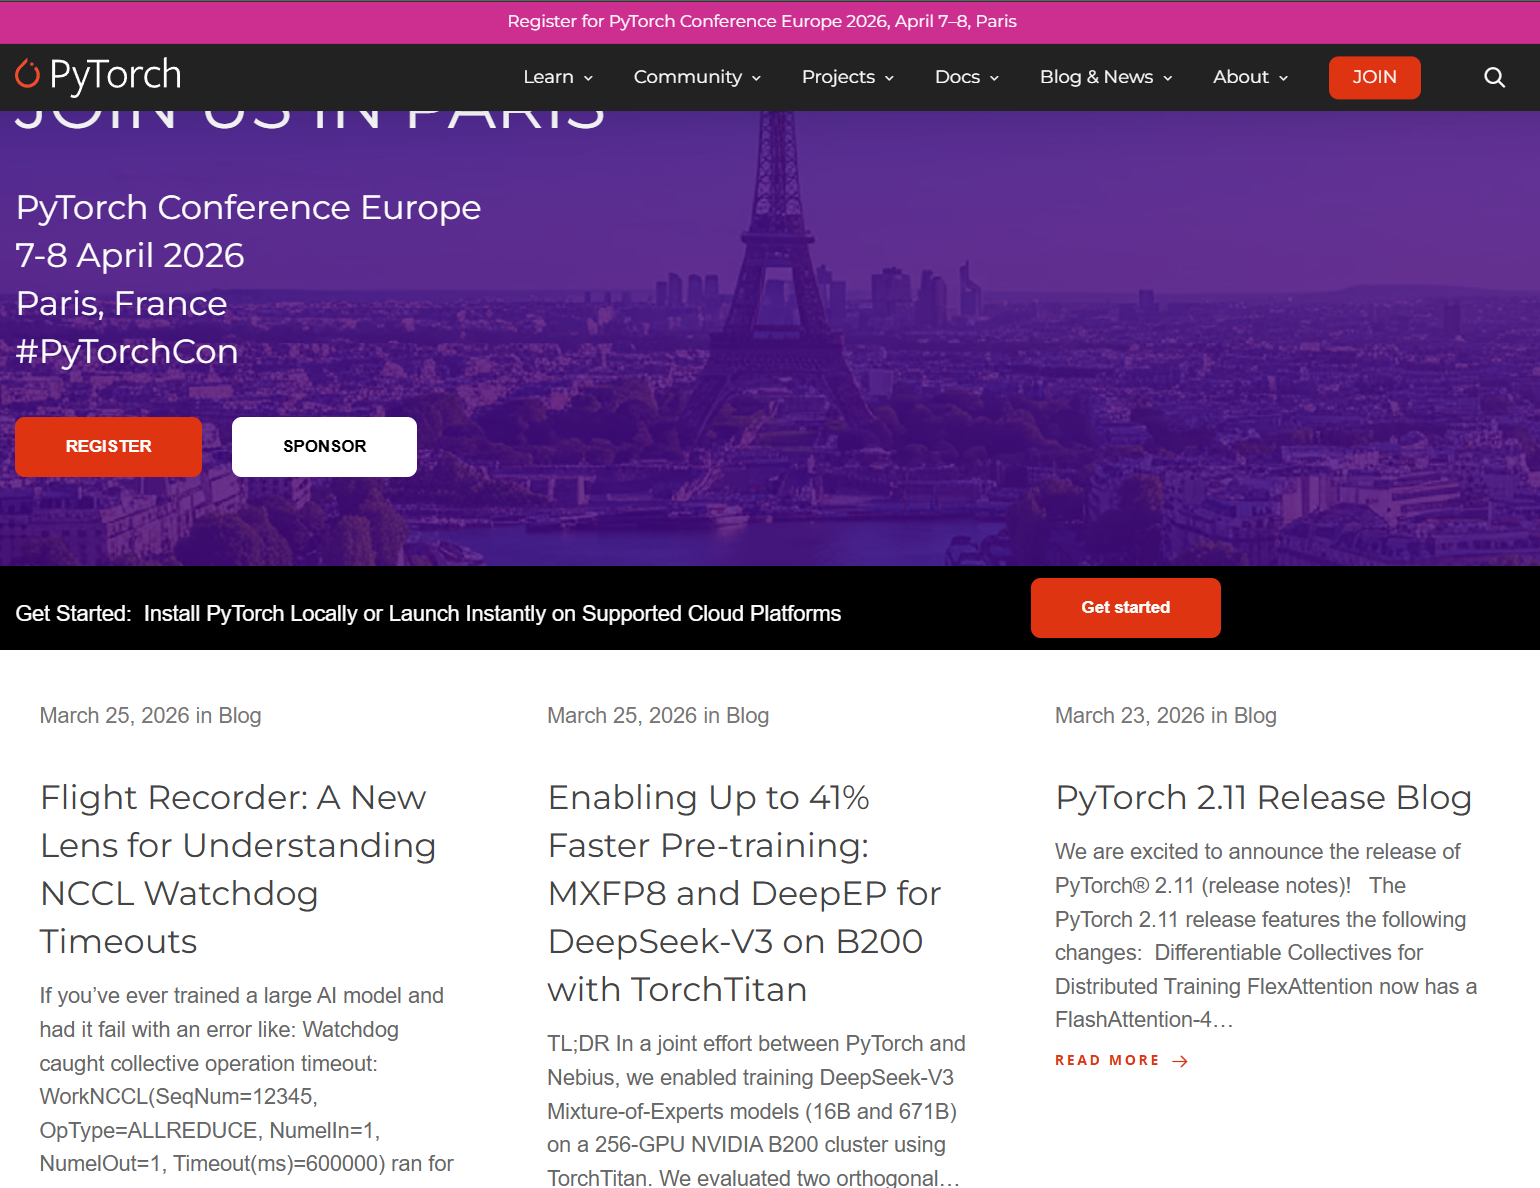

# Reference: [Pytorch Official Website](https://pytorch.org/)<br>
# Documents or Tutorials: [Start with Pytorch](https://docs.pytorch.org/docs/stable/index.html?_gl=1*4gmhfm*_up*MQ..*_ga*MTM4NzA4NTIyNC4xNzczNzQyODA1*_ga_469Y0W5V62*czE3NzM3NDI4MDUkbzEkZzEkdDE3NzM3NDI4NjIkajMkbDAkaDA.)

## **Lab Tasks Overview**

1. **Install Pytorch:** You can start on Colab (recommend for beginners) or with your own computer.
2. **Dynamic Computation Graph and Backpropagation:** Using PyTorch automatically gets gradients/derivatives of functions that we define.
3. **Learning by example:** Convolutional Neural Networks (CNNs) from scratch in PyTorch.
<br>

# Task 1: Install Pytorch

```
Start Locally and start on Colab
```



PyTorch is a highly adaptable deep learning framework designed to run seamlessly across a diverse range of hardware and operating systems. Whether you're on **macOS**, **Linux**, or **Windows**, you can install and utilize PyTorch, often through convenient package managers like Conda or Pip. Furthermore, PyTorch's flexibility extends to hardware acceleration: you can leverage the raw power of your **NVIDIA GPUs** (when installed with CUDA support) for significantly faster computations, or effortlessly run your models on **CPUs** for broader compatibility or when a GPU isn't available. This ability to cater to different OS preferences and hardware configurations, from the latest GPUs to standard CPUs, makes PyTorch an accessible and powerful choice for both beginners and seasoned researchers alike.

On Google Colab, make sure that you have selected a GPU in your runtime setup (in the menu, check under `Runtime -> Change runtime type`).
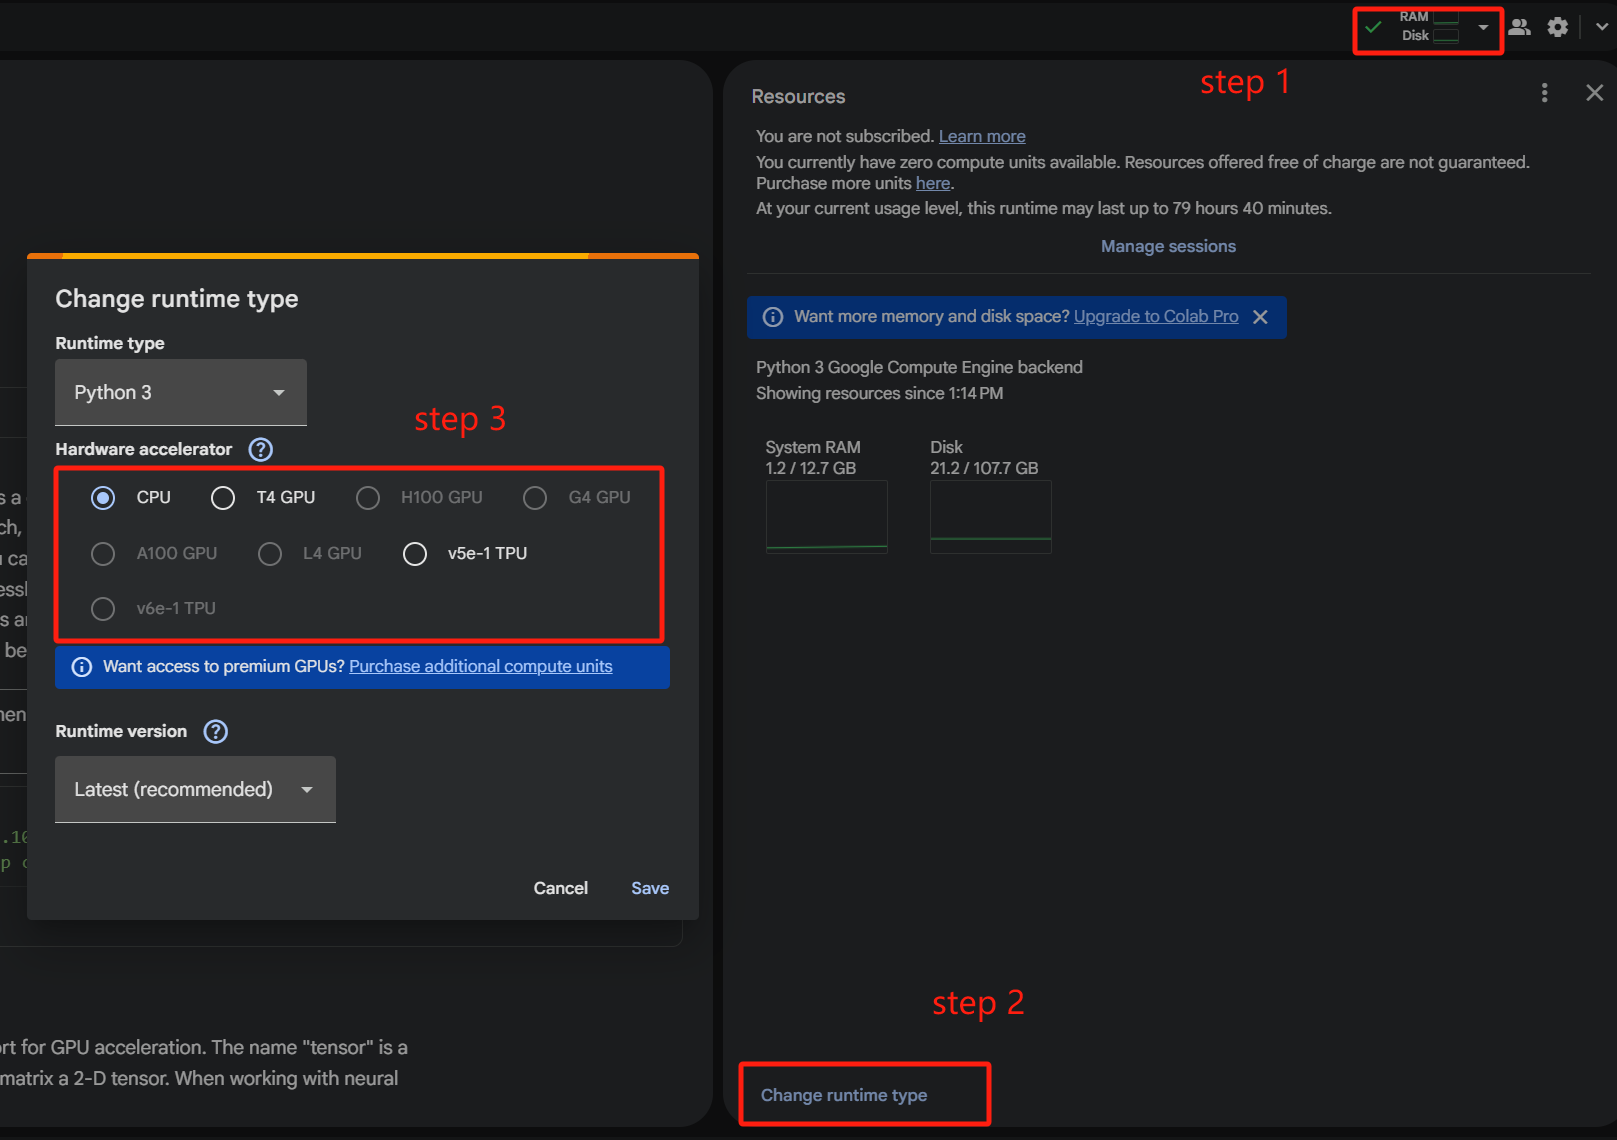

In [3]:
import torch
print("Using torch", torch.__version__) # for cpu, it will be torch 2.10.0+cpu
print(torch.cuda.is_available()) # Should print True if CUDA is set up correctly


Using torch 2.9.1
False


## If you want to try this lab on your computer, first install Pytorch, refer to the command on pytorch website.
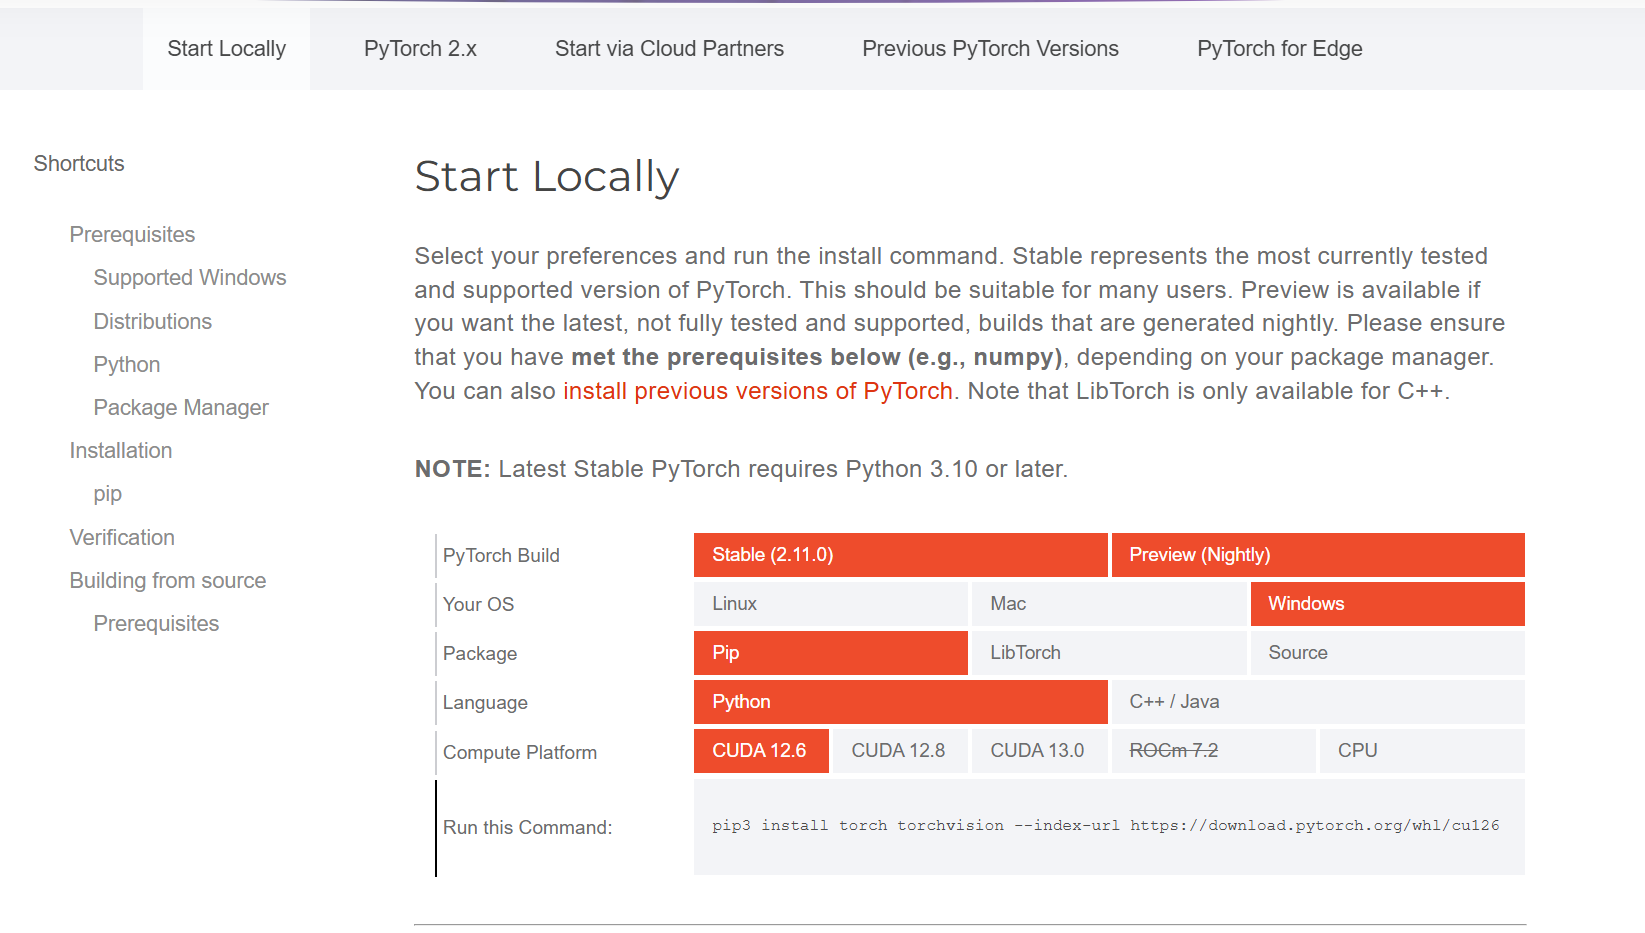

#Task 2: Dynamic Computation Graph and Backpropagation

One of the main reasons for using PyTorch in Deep Learning projects is that we can automatically get **gradients/derivatives** of functions that we define. We will mainly use PyTorch for implementing neural networks, and they are just fancy functions. If we use weight matrices in our function that we want to learn, then those are called the **parameters** or simply the **weights**.

If our neural network were to output a single scalar value, we would talk about taking the **derivative**, but you will see that quite often we will have **multiple** output variables ("values"); in that case, we talk about **gradients**. It's a more general term.

Given an input $\mathbf{x}$, we define our function by **manipulating** that input, usually by matrix-multiplications with weight matrices and additions with so-called bias vectors. As we manipulate our input, we are automatically creating a **computational graph**. This graph shows how to arrive at our output from our input.
PyTorch is a **define-by-run** framework; this means that we can just do our manipulations, and PyTorch will keep track of that graph for us. Thus, we create a dynamic computation graph along the way.

So, to recap: the only thing we have to do is to compute the **output**, and then we can ask PyTorch to automatically get the **gradients**.

> **Note:  Why do we want gradients?** Consider that we have defined a function, a neural net, that is supposed to compute a certain output $y$ for an input vector $\mathbf{x}$. We then define an **error measure** that tells us how wrong our network is, how bad it is in predicting output $y$ from input $\mathbf{x}$. Based on this error measure, we can use the gradients to **update** the weights $\mathbf{W}$ that were responsible for the output, so that the next time we present input $\mathbf{x}$ to our network, the output will be closer to what we want.

The first thing we have to do is to specify which tensors require gradients. By default, when we create a tensor, it does not require gradients.

In [ ]:
x = torch.ones((3,))
print(x.requires_grad)
print(x.grad)
print(x[0])
# print(x.item())
print(x[0].item())

False
None
tensor(1.)


RuntimeError: a Tensor with 3 elements cannot be converted to Scalar

We can change this for an existing tensor using the function `requires_grad_()` (underscore indicating that this is an in-place operation). Alternatively, when creating a tensor, you can pass the argument `requires_grad=True` to most initializers we have seen above.

In order to get familiar with the concept of a computation graph, we will create one for the following function:

$$y = \frac{1}{\ell(x)}\sum_i \left[(x_i + 2)^2 + 3\right],$$

where we use $\ell(x)$ to denote the number of elements in $x$. In other words, we are taking a mean here over the operation within the sum. You could imagine that $x$ are our parameters, and we want to optimize (either maximize or minimize) the output $y$. For this, we want to obtain the gradients $\partial y / \partial \mathbf{x}$. For our example, we'll use $\mathbf{x}=[0,1,2]$ as our input.

In [ ]:
# TODO: Define x
# Hint: Only float tensors can have gradients

print("x tensor: ", x)

Now let's build the computation graph step by step. You can combine multiple operations in a single line, but we will separate them here to get a better understanding of how each operation is added to the computation graph.

In [ ]:
# TODO: build the computation graph step by step

print("y tensor: ", y)

Using the statements above, we have created a computation graph that looks similar to the figure below:

<center style="width: 100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial2/pytorch_computation_graph.svg?raw=1" width="200px"></center>

We calculate $a$ based on the inputs $x$ and the constant $2$, $b$ is $a$ square, and so on. The visualization is an abstraction of the dependencies between the inputs and outputs of the operations we have applied.
Each node of the computation graph automatically defines a function for calculating the gradients with respect to its inputs, `grad_fn`. You can see this when we printed the output tensor $y$. This is why the computation graph is usually visualized in the reverse direction (arrows point from the result to the inputs). We can perform backpropagation on the computation graph by calling the function `backward()` on the last output, which effectively calculates the gradients for each tensor that has the property `requires_grad=True`:

In [ ]:
y.backward()

`x.grad` will now contain the gradient $\partial y/ \partial \mathcal{x}$, and this gradient indicates how a change in $\mathbf{x}$ will affect output $y$ given the current input $\mathbf{x}=[0,1,2]$:

In [ ]:
print(x.grad)

We can also verify these gradients by hand. We will calculate the gradients using the chain rule, in the same way as PyTorch did:

$$\frac{\partial y}{\partial x_i} = \frac{\partial y}{\partial c_i}\frac{\partial c_i}{\partial b_i}\frac{\partial b_i}{\partial a_i}\frac{\partial a_i}{\partial x_i}$$

Note that we have simplified this equation to index notation, and by using the fact that all operation besides the mean do not combine the elements in the tensor. The partial derivatives are:

$$
\frac{\partial a_i}{\partial x_i} = 1,\hspace{1cm}
\frac{\partial b_i}{\partial a_i} = 2\cdot a_i\hspace{1cm}
\frac{\partial c_i}{\partial b_i} = 1\hspace{1cm}
\frac{\partial y}{\partial c_i} = \frac{1}{3}
$$

Hence, with the input being $\mathbf{x}=[0,1,2]$, our gradients are $\partial y/\partial \mathbf{x}=[4/3,2,8/3]$. The previous code cell should have printed the same result.

It's meant only for students who have studied multivariable calculus

# Task 3: Convolutional Neural Networks (CNNs) from Scratch in PyTorch

We will be building CNNs from scratch in PyTorch, and seeing them in action as we train and test them on a real-world dataset.

We will then look into PyTorch and start by loading the CIFAR10 dataset using torchvision (a library containing various datasets and helper functions related to computer vision). We will then build and train our CNN from scratch. Finally, we will test our model.

In [ ]:
# Load in relevant libraries, and alias where appropriate
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# Define relevant variables for the ML task
batch_size = 64
num_classes = 10
learning_rate = 0.001
num_epochs = 20

# The device will determine whether to run the training on the GPU or the CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Dataset Loading

1. We start by writing some transformations. We resize the images, convert them to tensors and normalize them by using the mean and standard deviation of each band in the input images. You can calculate these as well, but they are available online.
2. Then, we load the dataset: both training and testing. We set download equal to True so that it is downloaded if not already downloaded.
Loading the whole dataset into the RAM at once is not a good practice and can seriously halt your computer. That’s why we use data loaders, which allow you to iterate through the dataset by loading the data in batches.
We then create two data loaders (for train/test) and set the batch size, along with shuffle, equal to True, so that images from each class are included in a batch.

In [ ]:
# Use transforms.compose method to reformat images for modeling,
# and save to a variable all_transforms for later use
all_transforms = transforms.Compose([transforms.Resize((32,32)),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                                          std=[0.2023, 0.1994, 0.2010])
                                     ])

# TODO: Create Training and Test dataset
# Hint: use torchvision.datasets


# TODO: Instantiate loader objects to facilitate processing
# Hint: use torch.utils.data.DataLoader


## CNN from Scratch

In [ ]:
# Creating a CNN class
class ConvNeuralNet(nn.Module):
#  Determine what layers and their order in the CNN object
    def __init__(self, num_classes):
        super(ConvNeuralNet, self).__init__()
        # TODO: Define the structure of the ConvNeuralNet
        # Hint: use nn.Conv2d and nn.MaxPool2d, you can define the structure by yourself


    # Progresses data across layers
    def forward(self, x):
        # TODO: complete forward of the ConvNeuralNet
        # Hint: refer to the network structure defined by yourself

        return out

##  Setting Hyperparameters

In [ ]:
model = ConvNeuralNet(num_classes).to(device)

# Set the Loss function with criterion
criterion = nn.CrossEntropyLoss()

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)

total_step = len(train_loader)

## Training

In [ ]:
# TODO: complete the training process
# Hint: Move tensors to the configured device
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # TODO: Forward pass


        # TODO: Backward and optimize


    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

# Testing

In [ ]:
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the {} train images: {} %'.format(50000, 100 * correct / total))

## This is an ungraded lab. You do not need to submit anything.

## Just enjoy this lab!